In [7]:
import sys
import time
from pathlib import Path

import duckdb
from src.features import build_feature_matrix

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DB_PATH = ROOT / "data" / "home_credit.db"
conn = duckdb.connect(str(DB_PATH))

t0 = time.perf_counter()
df = build_feature_matrix(conn)
conn.close()
elapsed = time.perf_counter() - t0
print(f"First load (build_feature_matrix): {elapsed:.3f} s")
print(df.shape)

First load (build_feature_matrix): 0.156 s
(307511, 143)


**MLflow** — each model logs params, test metrics, and the fitted `Pipeline` under the experiment `credit-risk-modelling`. Tracking uses `mlflow.db` (SQLite) at the repo root; large artifacts still go under `mlruns/`. From the repo root, view runs: `mlflow ui --backend-store-uri sqlite:///mlflow.db` (http://localhost:5000).

### Data preperation

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Dev: set to e.g. 0.05 for a 5% sample (faster fit/debug); None = full data.
SAMPLE_FRAC = None
if SAMPLE_FRAC is not None:
    df = df.sample(
        frac=SAMPLE_FRAC,
        random_state=42,
    ).reset_index(drop=True)

# Base features from `df`: exclude label and applicant id
X = df.drop(columns=["TARGET", "SK_ID_CURR"])
y = df["TARGET"]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (246008, 141), y_train shape: (246008,)
X_test shape: (61503, 141), y_test shape: (61503,)


## Logistic regression

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.metrics import (
    binary_classifier_metrics,
    format_metrics_lines,
    plot_roc_pr_curves,
)
from src.mlflow_helpers import log_pipeline_run

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
                max_categories=50,
                min_frequency=0.001,
            ),
        ),
    ]
)


preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    n_jobs=-1,
)
logit = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "clf",
            LogisticRegression(
                max_iter=2000,
                solver="liblinear",
                class_weight="balanced",
                tol=1e-3,
                random_state=42,
            ),
        ),
    ]
)

logit.fit(X_train, y_train)
y_score = logit.predict_proba(X_test)[:, 1]
y_pred = logit.predict(X_test)

test_metrics = binary_classifier_metrics(y_test, y_score, y_pred=y_pred)

log_pipeline_run(
    "logistic_regression",
    logit,
    metrics=test_metrics,
    params={
        "classifier": "LogisticRegression",
        "max_iter": 2000,
        "solver": "liblinear",
        "class_weight": "balanced",
        "tol": 1e-3,
        "random_state": 42,
        "test_size": 0.2,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "n_features": int(X.shape[1]),
    },
    signature_sample=X_test.iloc[:500],
)

print("Logistic regression — test set")
print(format_metrics_lines(test_metrics))

/Users/b.evans/Documents/ml_development/credit-risk-ml/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/04/11 19:58:40 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/b.evans/Documents/ml_development/credit-risk-ml
2026/04/11 19:58:40 WARNING mlflow.skl

Logistic regression — test set
Accuracy: 0.6964
ROC-AUC: 0.7565
Gini (2×AUC − 1): 0.5129
Average precision (PR-AUC): 0.2355
KS statistic: 0.3853


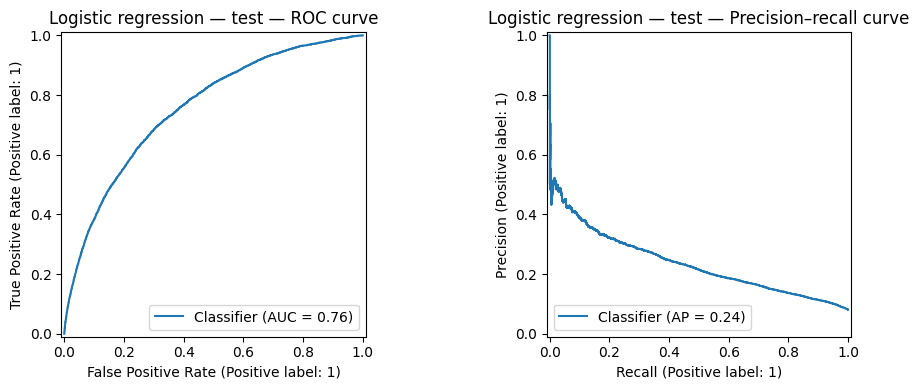

In [17]:
fig = plot_roc_pr_curves(y_test, y_score, title_prefix="Logistic regression — test — ")

## XGBoost

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from src.mlflow_helpers import log_pipeline_run

# Same train/test split and `categorical_pipe` / `num_cols` / `cat_cols` as logistic regression
tree_numeric_pipe = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))],
)
tree_preprocess = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    n_jobs=-1,
)

scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())

xgb_clf = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
)

xgb_model = Pipeline(steps=[("preprocess", tree_preprocess), ("clf", xgb_clf)])
xgb_model.fit(X_train, y_train)

y_score_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

xgb_metrics = binary_classifier_metrics(y_test, y_score_xgb, y_pred=y_pred_xgb)

log_pipeline_run(
    "xgboost",
    xgb_model,
    metrics=xgb_metrics,
    params={
        "classifier": "XGBClassifier",
        "n_estimators": 400,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "tree_method": "hist",
        "eval_metric": "logloss",
        "scale_pos_weight": scale_pos_weight,
        "random_state": 42,
    },
    signature_sample=X_test.iloc[:500],
)

print("XGBoost — test set")
print(format_metrics_lines(xgb_metrics))

/Users/b.evans/Documents/ml_development/credit-risk-ml/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/04/11 20:03:14 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/b.evans/Documents/ml_development/credit-risk-ml
2026/04/11 20:03:14 WARNING mlflow.skl

XGBoost — test set
Accuracy: 0.7252
ROC-AUC: 0.7682
Gini (2×AUC − 1): 0.5364
Average precision (PR-AUC): 0.2595
KS statistic: 0.4059


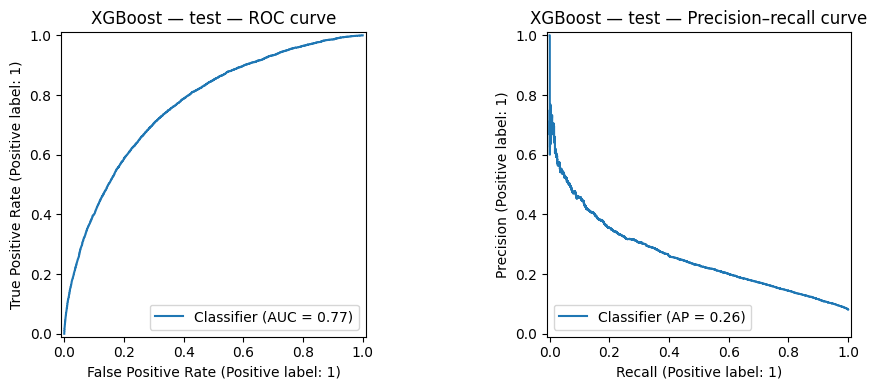

In [19]:
fig = plot_roc_pr_curves(y_test, y_score_xgb, title_prefix="XGBoost — test — ")

## LightGBM

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

from src.mlflow_helpers import log_pipeline_run

# Same layout as XGBoost (median impute + OHE; no scaling for trees)
tree_numeric_pipe = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))],
)
tree_preprocess = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    n_jobs=-1,
)

lgb_clf = LGBMClassifier(
    n_estimators=400,
    num_leaves=48,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    verbose=-1,
)

lgb_model = Pipeline(steps=[("preprocess", tree_preprocess), ("clf", lgb_clf)])
lgb_model.fit(X_train, y_train)

y_score_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_lgb = lgb_model.predict(X_test)

lgb_metrics = binary_classifier_metrics(y_test, y_score_lgb, y_pred=y_pred_lgb)

log_pipeline_run(
    "lightgbm",
    lgb_model,
    metrics=lgb_metrics,
    params={
        "classifier": "LGBMClassifier",
        "n_estimators": 400,
        "num_leaves": 48,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "class_weight": "balanced",
        "random_state": 42,
    },
    signature_sample=X_test.iloc[:500],
)

print("LightGBM — test set")
print(format_metrics_lines(lgb_metrics))

/Users/b.evans/Documents/ml_development/credit-risk-ml/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/b.evans/Documents/ml_development/credit-risk-ml/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/b.evans/Documents/ml_development/credit-risk-ml/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/b.evans/Documents/ml_development/credit-risk-ml/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing value

LightGBM — test set
Accuracy: 0.7429
ROC-AUC: 0.7691
Gini (2×AUC − 1): 0.5381
Average precision (PR-AUC): 0.2606
KS statistic: 0.4069


In [ ]:
fig = plot_roc_pr_curves(y_test, y_score_lgb, title_prefix="LightGBM — test — ")